# 04_07 Watershed Delineation Part 1: Single-Outlet Drainage Basins

## 1. Introduction

The term *watershed* is often misunderstood.

Many people assume a watershed refers to a collection of lakes, rivers, wetlands, or other visible bodies of water.

In reality, a watershed is any area of land that sheds water and routes it toward a particular drainage point.

A watershed is not the water itself — it is the land that controls how water moves. A point on top of a hill sheds water and contributes water to rivers and lakes, therefore it is part of the watershed.

This shifts the question:

- Flow accumulation asks: "Where does water collect?"
- Drainage networks ask: "Which paths are most likely to become streams?"
- Watershed delineation asks: "Where did that water originate?"

Instead of focusing on visible water bodies, a watershed focuses on the contributing terrain that feeds them.

The watershed consists not only of rivers and lakes, but also the hills, slopes, valleys, and flow paths that supply them.

---

### Key conceptual shift

We shift from a forward view of flow:

> "Where does water go?"

to a reverse view:

> "Where could this water have come from?"

This reversal forms the foundation of watershed analysis.

---

### Real-world clarification

Large landscapes rarely contain only one drainage outlet.

Regions such as Waterloo contain:

- multiple rivers
- tributaries
- wetlands
- sub-basins
- nested drainage systems

However, beginning with a single outlet allows the watershed concept to be learned clearly before studying more complex cases involving multiple outlets.

---

### Mathematical definition

Given an outlet point P:

$$
W(P)=\{(x,y)\;|\;(x,y)\rightarrow P\}
$$

The watershed consists of every cell whose flow path eventually reaches the outlet.

In other words:

> The watershed is all land that contributes water to a chosen drainage point.

## 2. Imports

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## 3. Load Data

In [3]:
with rasterio.open("../../data/Elevation/clipped_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata

dem = np.where(dem == nodata, np.nan, dem)

## 4. Flow Direction Preprocessing

This notebook recomputes the flow direction field from the DEM.

The gradient of elevation gives the direction of steepest descent at each cell, showing the direction that water would naturally flow.

There are two ways to think about flow contribution.

- Starting at a drainage point and tracing all cells that contribute to it.
- Starting at a cell and following where that water eventually goes to see if it reaches the target outlet.

Both approaches describe the same physical system.

For the single-outlet model we will begin at the outlet and trace contributing cells upstream.

This allows us to answer:

> Which parts of the landscape supply water to this location?

Note that in the field, it is also often easiest to think upstream. A researcher standing at a stream, lake, or drainage outlet can visually identify the water flowing into that location and trace the watershed backward.

In [4]:
rows, cols = dem.shape

mean_lat = (bounds.top + bounds.bottom) / 2

lat_m = 111320
lon_m = 111320 * np.cos(np.radians(mean_lat))

dx_spacing = lon_m * (bounds.right - bounds.left) / cols
dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

dy, dx = np.gradient(
    np.nan_to_num(dem),
    dy_spacing,
    dx_spacing
)

flow_dx = -dx
flow_dy = -dy

# 5. D8 Flow Routing

The D8 model assumes that water flows toward one of the eight neighboring cells in the direction of steepest descent.

Each cell therefore has a single downstream flow path.

For the single-outlet watershed model we reverse this process.

Beginning at the outlet, we trace all upstream cells whose flow paths eventually reach that location.

Several physical processes such as:

- soil absorption
- evaporation
- infiltration
- surface roughness
- friction

Flow can become stronger or weaker over distance as it reaches the accumulation zone, or drainage outlet. This can be due to water loss along the flow path, reduced velocity due to friction or impedances, or increased velocity as potential energy converts to kinetic energy. 

may alter real water movement.

However, these effects are ignored in the present model so that we can focus entirely on terrain-controlled flow.

More advanced models may later include these processes to make them more realistic.

More advanced models may also explore alternative computational strategies to improve efficiency in the watershed delineation step, often by introducing additional preprocessing of flow connectivity or by using graph-based representations of flow paths.

In [5]:
row_offset = np.nan_to_num(
    np.sign(flow_dy),
    nan=0
).astype(int)

col_offset = np.nan_to_num(
    np.sign(flow_dx),
    nan=0
).astype(int)

target_row = np.clip(
    np.arange(rows)[:, None] + row_offset,
    0,
    rows - 1
)

target_col = np.clip(
    np.arange(cols)[None, :] + col_offset,
    0,
    cols - 1
)

## 6. Select Watershed Outlet

To demonstrate the concept, we first select a single drainage outlet.

Several situations may justify this approach:

- studying water flow into a specific lake or pond
- studying a particular stream location to estimate the influx of water at a point along the stream.
- investigating a known drainage point and trying to learn more about it
- simplifying a localized study area that may only have one major drainage point where the others are considered negligible
- exploring an unfamiliar region to locate important drainage areas

In this notebook we select the cell with the highest accumulation value.

This provides a reproducible outlet that can later be replaced with any known drainage location.

In [6]:
accumulation = np.ones((rows, cols))

for _ in range(100):

    new_acc = accumulation.copy()

    for r in range(rows):
        for c in range(cols):

            rr = target_row[r, c]
            cc = target_col[r, c]

            if rr != r or cc != c:
                new_acc[rr, cc] += accumulation[r, c]

    accumulation = new_acc

outlet = np.unravel_index(
    np.nanargmax(accumulation),
    accumulation.shape
)

print("Outlet cell:", outlet)

Outlet cell: (np.int64(672), np.int64(458))


In [7]:
r, c = outlet

# cell size in map units (usually meters if projected CRS)
cell_width = (bounds.right - bounds.left) / cols
cell_height = (bounds.top - bounds.bottom) / rows

# convert grid index → spatial coordinates (center of cell)
x = bounds.left + (c + 0.5) * cell_width
y = bounds.top - (r + 0.5) * cell_height

print("Outlet (row, col):", outlet)
print("Outlet coordinates (x, y):", (x, y))

Outlet (row, col): (np.int64(672), np.int64(458))
Outlet coordinates (x, y): (np.float64(-80.6942793219061), np.float64(43.433065953864805))


# 7. Watershed Delineation

Beginning at the outlet, we trace flow paths upstream.

Any cell whose flow path eventually reaches the outlet belongs to the watershed.

This is the reverse of flow accumulation.

Instead of asking:

> Where does water go?

or:

> Which cell does water flow to next?"

we ask:

> Where did the water come from?

or 

> Which cells feed into this cell?

 And repeat that process for each upstream cell along the flow path.

Cells inside the watershed receive a value of 1.

Cells outside the watershed receive a value of 0.

The resulting watershed therefore represents all terrain that contributes water to the chosen drainage point.

#### Disclosure/ Warning! 

Note that this implementation uses a brute-force upstream search.

For each cell in the grid, the algorithm repeatedly scans the full domain to determine whether that cell flows into another cell. This introduces significant computational overhead, since connectivity is recomputed many times during traversal.

In practice, this leads to approximately quadratic worst-case behavior relative to the number of cells in the domain, especially for large grids where many upstream connections must be explored.

This approach is still conceptually correct, but not computationally optimal.

A more efficient alternative is to precompute a reverse flow connectivity structure (i.e., a reverse adjacency representation of the D8 flow field). In that formulation, each cell stores a list of upstream contributors directly, allowing the watershed to be computed with a single linear traversal over the graph (approximately O(n) with respect to the number of cells). Which would be much faster. There is the possibility that while running this it may run for a long time or crash or freeze if the dataset is very large , or if there are many very long flow paths to trace. 

The current version is therefore prioritizing clarity and direct implementation of the flow concept, while more advanced implementations would shift this cost into a preprocessing step to improve performance.

In [37]:
watershed = np.zeros((rows, cols), dtype=bool)

stack = [outlet]

while stack:

    r, c = stack.pop()

    if watershed[r, c]:
        continue

    watershed[r, c] = True

    for rr in range(rows):
        for cc in range(cols):

            if (
                target_row[rr, cc] == r and
                target_col[rr, cc] == c
            ):
                stack.append((rr, cc))

## 8. Watershed Visualization

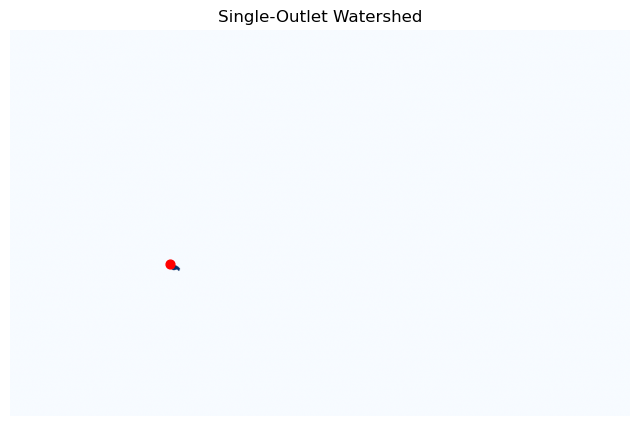

In [42]:
plt.figure(figsize=(8,8))

plt.imshow(
    watershed,
    cmap="Blues",
    origin="upper"
)

plt.scatter(
    outlet[1],
    outlet[0],
    color="red",
    s=40
)

plt.title("Single-Outlet Watershed")

plt.axis("off")

plt.show()

## 9. Terrain Overlay

Overlaying the watershed on the terrain helps reveal the geographic meaning of the result.

The result may initially appear surprising because only a relatively small area contributes to the selected outlet.

However, this does not indicate a failure of the method.

Instead, it teaches us something important about the landscape.

The selected outlet lies within the Waterloo Moraine where local topography produces a relatively small contributing basin.

The truth is not obligated to meet our expectations.

Unexpected results often reveal important features that might otherwise be overlooked.

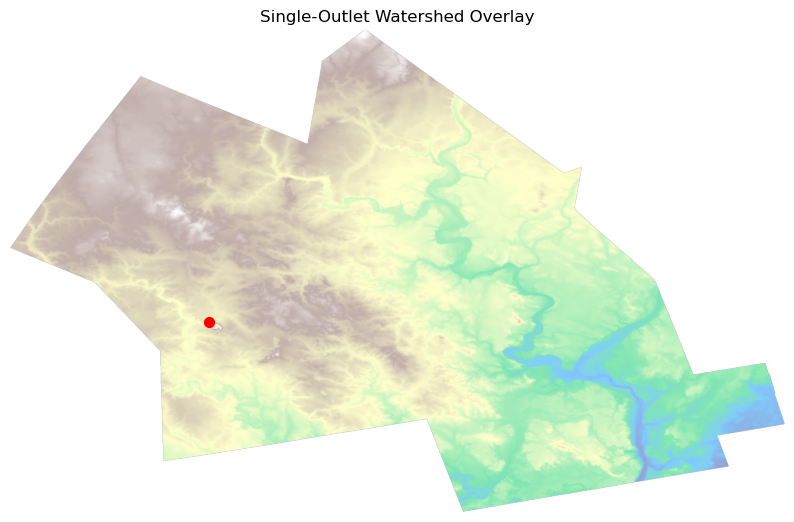

In [44]:
plt.figure(figsize=(10,10))

plt.imshow(
    dem,
    cmap="terrain",
    alpha=0.5,
    origin="upper"
)

plt.imshow(
    np.ma.masked_where(
        ~watershed,
        watershed
    ),
    cmap="Blues",
    alpha=0.6,
    origin="upper"
)

plt.scatter(
    outlet[1],
    outlet[0],
    color="red",
    s=50
)

plt.title("Single-Outlet Watershed Overlay")

plt.axis("off")

plt.show()

## 10. Interpretation

The resulting watershed is surprisingly small. We must ocnsider that the D8 model differs from relaity in that water only flows to one of 8 neighbouring cells. If the land is mostly flat then the flow directions will be quite erratic, and form short flow paths.

Rather than indicating an error, this reveals that the chosen outlet receives relatively more water from a localized contributing area.

Inspection of the terrain suggests that this location corresponds closely to the area around Spongy Lake near Baden.

Spongy Lake is an ecologically important wetland system within Waterloo Region, that may not be immediately obvious.

This illustrates an important strength of watershed analysis.

Terrain alone can reveal locations that may have significant ecological importance.

Major drainage areas often correspond to:

- wetlands
- recharge zones
- ponds
- lakes
- stream origins
- ecologically sensitive habitats

Similar methods may therefore help identify important locations in unfamiliar landscapes.

Several observations emerge:

- watershed boundaries arise naturally from terrain
- nearby cells may belong to different drainage systems
- high elevations do not necessarily contribute to the same outlet
- small contributing areas can still represent important ecological locations

The watershed therefore provides a direct connection between topography and ecology.

## 11. Conclusion

This notebook introduces watershed delineation using a single outlet.

Beginning with elevation, we have now derived:

- slope
- flow direction
- accumulation
- drainage networks
- watershed boundaries

The watershed reverses the usual perspective.

Instead of asking:

> Where does water go?

we ask:

> Where did the water come from?

Although real landscapes contain many outlets and overlapping drainage systems, the single-outlet model provides an important conceptual foundation.

Future notebooks will extend this idea by considering:

- multiple outlets
- continuous contribution fields
- thresholded watersheds
- regional drainage structure
- groundwater and infiltration processes

These extensions will provide a more complete picture of how landscapes organize water movement.